# Topic Analysis of ECtHR Article 6 Cases — Three Methods Compared

Standalone companion to `echr.ipynb`. Compares three topic-modelling methods on the same Article 6 corpus (436 cases, 75/25 stratified split, seed 42), each probing the corpus from a different representation:

| Method | Input representation | What it tells us |
|---|---|---|
| **A. BERTopic / MiniLM** | Dense 384-d contrastive sentence embeddings | General-domain semantic similarity |
| **B. NMF on TF-IDF** | Sparse 12k-d lemma n-grams | Lexical co-occurrence (same vectors the SVM sees) |
| **C. BERTopic / LegalBERT** | Dense 768-d chunked LegalBERT CLS mean | Domain-pretrained semantic similarity |

**Key question.** When three different encoders cluster the same corpus, do they recover the same structure? If they do — and in this notebook they substantially do — the country-register clustering `echr.ipynb` §§5 / 11.1 / 11.5 reports is not a TF-IDF artefact. It is *in* the corpus, visible through any reasonable representation.

**Contents**
1. Setup — data loading, tokeniser, train/test split
2. TF-IDF baseline (anchors the leaderboard)
3. Method A — BERTopic / MiniLM: topic words, UMAP scatter, per-country heatmap, topic-by-outcome
4. Method B — NMF on TF-IDF: topic words, per-country heatmap, topic-by-outcome
5. Method C — BERTopic / LegalBERT (frozen, chunked): topic words, per-country heatmap, topic-by-outcome
6. Model Performance — comprehensive leaderboard across all 3 topic methods × (topic-only, TF-IDF+topic) × (SVM, LR)
7. Cross-method comparison and discussion

**Self-contained.** No imports from `scripts/*.py`. Seeds fixed to 42 throughout. LegalBERT embeddings are cached to `results/topic_bertopic_legalbert_embs.npz` on first run.

**Runtime.** ~5–10 min on CPU, dominated by the first LegalBERT embedding extraction; subsequent runs reload the cache.

## 1. Setup

In [1]:
import os, re, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

RANDOM_STATE   = 42
DATA_PATH      = 'data/processed/processed.csv'
MINILM_MODEL   = 'sentence-transformers/all-MiniLM-L6-v2'
LEGALBERT_NAME = 'nlpaueb/legal-bert-base-uncased'
LB_CACHE       = 'results/topic_bertopic_legalbert_embs.npz'
N_TOPICS       = 10

# ── NLTK bootstrap ────────────────────────────────────────────────────────
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords as nltk_stopwords
for pkg_path, pkg_name in [('corpora/stopwords','stopwords'),
                            ('corpora/wordnet','wordnet'),
                            ('corpora/omw-1.4','omw-1.4')]:
    try: nltk.data.find(pkg_path)
    except LookupError: nltk.download(pkg_name, quiet=True)

wnl = WordNetLemmatizer()
LEGAL_EXTRA_STOPWORDS = {'mr','mrs','ms','court','case'}
ALL_STOPWORDS = set(nltk_stopwords.words('english')) | LEGAL_EXTRA_STOPWORDS
MANUAL_LEMMA_MAP = {
    'applicants':'applicant', 'authorities':'authority', 'proceedings':'proceeding',
    'judges':'judge', 'lawyers':'lawyer', 'officers':'officer',
    'children':'child', 'women':'woman', 'men':'man',
}

def _norm(tok):
    tok = tok.lower().strip()
    tok = MANUAL_LEMMA_MAP.get(tok, tok)
    if not re.search(r'[a-z]', tok): return ''
    return wnl.lemmatize(tok, pos='n')

def legal_tokenizer(text):
    return [t for tok in re.findall(r"[a-z']+", str(text).lower())
            if (t := _norm(tok)) and len(t) > 2 and t not in ALL_STOPWORDS]

print('Setup complete. Seed =', RANDOM_STATE)

Setup complete. Seed = 42


In [2]:
# ── Load Article 6 subset + 75/25 stratified split ─────────────────────────
from sklearn.model_selection import train_test_split

df = pd.read_csv(DATA_PATH)
def _contains_6(s): return s.astype(str).str.split(';').apply(lambda a: '6' in a)
v  = _contains_6(df['violation_articles'])
nv = _contains_6(df['nonviolation_articles'])
df6 = df[v | nv].copy()
df6['label_art6'] = v[df6.index].astype(int)
df6 = df6.reset_index(drop=True)

X   = df6['text'].values
y   = df6['label_art6'].values
idx = np.arange(len(df6))
X_train, X_test, y_train, y_test, i_train, i_test = train_test_split(
    X, y, idx, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
df_train = df6.iloc[i_train].reset_index(drop=True)
df_test  = df6.iloc[i_test].reset_index(drop=True)

print(f'Article 6 subset: {len(df6)} cases  |  violation rate: {df6["label_art6"].mean():.2%}')
print(f'Train: {len(X_train)} (violation rate {y_train.mean():.2%})')
print(f'Test : {len(X_test)}  (violation rate {y_test.mean():.2%})')
print('\nRespondent counts:')
print(df6['respondent'].value_counts().to_string())

Article 6 subset: 436 cases  |  violation rate: 73.39%
Train: 327 (violation rate 73.39%)
Test : 109  (violation rate 73.39%)

Respondent counts:
respondent
RUS    167
GBR    148
TUR    121


## 2. TF-IDF Baseline

Same pipeline as `echr.ipynb` §6. Anchors the leaderboard before any topic features are added.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
from scipy.sparse import hstack, csr_matrix, issparse

def make_tfidf():
    return TfidfVectorizer(tokenizer=legal_tokenizer, preprocessor=None,
                            token_pattern=None, lowercase=False,
                            min_df=3, max_df=0.90, sublinear_tf=True,
                            ngram_range=(1,2))

def make_topic_cv():
    """CountVectorizer for BERTopic c-TF-IDF topic-word extraction."""
    return CountVectorizer(tokenizer=legal_tokenizer, preprocessor=None,
                            token_pattern=None, lowercase=False,
                            min_df=2, max_df=0.95, ngram_range=(1, 2))

def tune_and_eval(Xtr, Xte, name):
    """GridSearchCV over C × class_weight for SVM and LR on one feature set."""
    param_grid = {'clf__C': [0.01,0.05,0.1,0.5,1.0,5.0,10.0],
                  'clf__class_weight': [None, 'balanced']}
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    for clf_name, cls, extra in [('SVM', LinearSVC, {'max_iter':2000}),
                                   ('LR',  LogisticRegression, {'max_iter':1000})]:
        gs = GridSearchCV(Pipeline([('clf', cls(**extra, random_state=RANDOM_STATE))]),
                          param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, refit=True)
        gs.fit(Xtr, y_train)
        pred = gs.best_estimator_.predict(Xte)
        rows.append({
            'Features': name, 'Classifier': clf_name,
            'Accuracy': round(accuracy_score(y_test, pred), 3),
            'Macro-F1': round(f1_score(y_test, pred, average='macro'), 3),
            'F1 (V)':   round(f1_score(y_test, pred, pos_label=1), 3),
            'F1 (NV)':  round(f1_score(y_test, pred, pos_label=0), 3),
            'C': gs.best_params_['clf__C'],
            'cw': str(gs.best_params_['clf__class_weight']),
        })
        print(f'  {name} / {clf_name}: macro-F1 = {rows[-1]["Macro-F1"]}  '
              f'(C={rows[-1]["C"]}, cw={rows[-1]["cw"]})')
    return rows

all_results = []

print('=== TF-IDF baseline ===')
tfidf = make_tfidf()
Xtr_tfidf = tfidf.fit_transform(X_train)
Xte_tfidf = tfidf.transform(X_test)
print(f'TF-IDF vocab: {len(tfidf.get_feature_names_out())}  |  Xtr shape: {Xtr_tfidf.shape}')
all_results += tune_and_eval(Xtr_tfidf, Xte_tfidf, 'TF-IDF only')

=== TF-IDF baseline ===


TF-IDF vocab: 12429  |  Xtr shape: (327, 12429)


  TF-IDF only / SVM: macro-F1 = 0.734  (C=0.01, cw=balanced)


  TF-IDF only / LR: macro-F1 = 0.743  (C=1.0, cw=balanced)


## Shared helper — topic diagnostics

Each topic method below is rendered with the same three diagnostics so they can be compared at a glance:
1. **Top words per topic** — what does each cluster look like lexically?
2. **Per-country heatmap** (row-normalised) — does the clustering align with respondent country?
3. **Topic-by-outcome** — which topics skew toward violation vs. non-violation on the training set?

In [4]:
def topic_diagnostics(get_top_words, topic_sizes, probs_train, topics_train,
                        countries, labels, method_name, K):
    """Renders top-words table + per-country heatmap + by-outcome table.
    `get_top_words(k)` returns a list of words for topic k (str list, len ≤ 10).
    `topic_sizes` is a {topic_id: count} dict."""
    # 1. Top words per topic
    rows = []
    for k in sorted(topic_sizes):
        if k == -1:
            label = 'Outliers'
        else:
            label = ', '.join(get_top_words(k)[:10])
        rows.append({'Topic': k, 'Size': int(topic_sizes[k]), 'Top words': label})
    tw_df = pd.DataFrame(rows)
    print(f'── {method_name}: top words per topic ──')
    print(tw_df.to_string(index=False, max_colwidth=100))

    # 2. Per-country heatmap (row-normalised)
    topic_cols = [f'T{i}' for i in range(K)]
    ct = pd.DataFrame(probs_train, columns=topic_cols)
    ct['country'] = countries
    mean_country = ct.groupby('country').mean()
    mean_norm    = mean_country.div(mean_country.sum(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=(8.5, 2.8))
    im = ax.imshow(mean_norm.values, cmap='viridis', aspect='auto', vmin=0, vmax=0.5)
    ax.set_xticks(range(K)); ax.set_xticklabels(topic_cols)
    ax.set_yticks(range(len(mean_norm.index))); ax.set_yticklabels(mean_norm.index)
    for i in range(mean_norm.shape[0]):
        for j in range(mean_norm.shape[1]):
            v = mean_norm.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v < 0.25 else 'black', fontsize=7)
    ax.set_title(f'{method_name} — mean topic probability by country (row-normalised)')
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    plt.tight_layout(); plt.show()

    # 3. Topic-by-outcome
    tw = pd.DataFrame(probs_train, columns=topic_cols)
    tw['label'] = labels
    mv  = tw[tw['label']==1].drop(columns='label').mean()
    mnv = tw[tw['label']==0].drop(columns='label').mean()
    out_df = pd.DataFrame({'Mean (V)': mv, 'Mean (NV)': mnv,
                            'ΔV-NV': (mv - mnv).round(3)}).round(3)
    out_df['Top words'] = [
        ', '.join(get_top_words(i)[:6]) if i in topic_sizes and i >= 0 else '—'
        for i in range(K)]
    out_df = out_df.sort_values('ΔV-NV', ascending=False)
    print(f'\n── {method_name}: topic weights by outcome (train set) ──')
    print(out_df.to_string(max_colwidth=80))

print('topic_diagnostics helper defined.')

topic_diagnostics helper defined.


## 3. Method A — BERTopic / MiniLM

`all-MiniLM-L6-v2` (22M params, contrastively trained for sentence similarity) embeds each FACTS document → UMAP → HDBSCAN → BERTopic reduces to `nr_topics=10` and extracts topic words via class-based c-TF-IDF using our `legal_tokenizer`.

UMAP: `n_neighbors=10, n_components=5, min_dist=0.0, cosine` · HDBSCAN: `min_cluster_size=10, min_samples=5`

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/103 [00:00<00:00, 5349.88it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 1/103 [00:00<00:00, 539.81it/s, Materializing param=embeddings.LayerNorm.bias] 

Loading weights:   2%|▏         | 2/103 [00:00<00:00, 744.40it/s, Materializing param=embeddings.LayerNorm.weight]

...

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 564.21it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 585.52it/s, Materializing param=pooler.dense.weight]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fitting BERTopic / MiniLM ...


Discovered topics: 9  |  outliers: 54/327
── Method A — BERTopic / MiniLM: top words per topic ──
 Topic  Size                                                                                            Top words
    -1    54                                                                                             Outliers
     0    64 security, public prosecutor, prosecutor, istanbul, statement, village, custody, organisation, ass...
     1    43  detention, district, cell, regional, prosecutor, remand, moscow, criminal proceeding, counsel, town
     2    38 regional, district, town, rub, enforcement, respondent, supervisory, supervisory review, bailiff,...
     3    34     jury, counsel, disclosure, solicitor, trial judge, defence, interview, petition, crown, material
     4    27 cassation, compensation, supreme administrative, labour, land, izmir, upheld judgment, istanbul, ...
     5    19           child, care, parent, social, access, foster, contact, social worker, foster paren

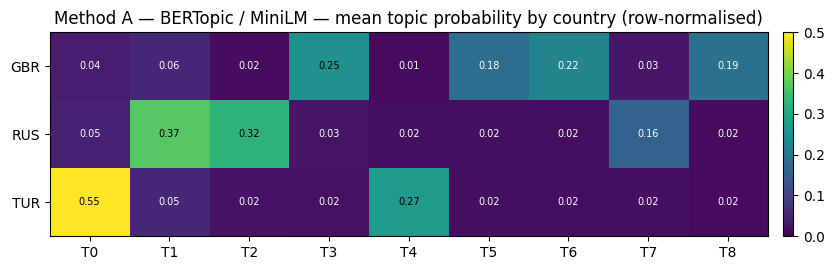


── Method A — BERTopic / MiniLM: topic weights by outcome (train set) ──
    Mean (V)  Mean (NV)  ΔV-NV                                                              Top words
T4     0.082      0.038  0.043   cassation, compensation, supreme administrative, labour, land, izmir
T1     0.160      0.135  0.025                detention, district, cell, regional, prosecutor, remand
T7     0.073      0.048  0.024                    moscow, meeting, russian, people, square, detention
T2     0.126      0.104  0.021                 regional, district, town, rub, enforcement, respondent
T8     0.055      0.058 -0.002             defence, trafficking, prosecution, confiscation, gbp, drug
T0     0.149      0.151 -0.003  security, public prosecutor, prosecutor, istanbul, statement, village
T6     0.064      0.071 -0.007                  inspector, tax, magistrate, section, interview, share
T3     0.068      0.104 -0.036             jury, counsel, disclosure, solicitor, trial judge, defence
T5     0

In [5]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer

def make_umap(): return UMAP(n_neighbors=10, n_components=5, min_dist=0.0,
                              metric='cosine', random_state=RANDOM_STATE)
def make_hdbscan(): return HDBSCAN(min_cluster_size=10, min_samples=5,
                                    metric='euclidean', prediction_data=True)

embed_model_ml = SentenceTransformer(MINILM_MODEL, device='cpu')
bt_ml = BERTopic(embedding_model=embed_model_ml,
                  umap_model=make_umap(), hdbscan_model=make_hdbscan(),
                  vectorizer_model=make_topic_cv(), nr_topics=N_TOPICS,
                  calculate_probabilities=True, verbose=False)

print('Fitting BERTopic / MiniLM ...')
t_ml_tr, p_ml_tr = bt_ml.fit_transform(list(X_train))
p_ml_tr = np.nan_to_num(np.atleast_2d(p_ml_tr), nan=0.0)
t_ml_te, p_ml_te = bt_ml.transform(list(X_test))
p_ml_te = np.nan_to_num(np.atleast_2d(p_ml_te), nan=0.0)

ml_sizes = {int(t): int(c) for t, c in zip(bt_ml.get_topic_info()['Topic'],
                                             bt_ml.get_topic_info()['Count'])}
print(f'Discovered topics: {sum(1 for k in ml_sizes if k >= 0)}  '
      f'|  outliers: {ml_sizes.get(-1, 0)}/{len(t_ml_tr)}')

topic_diagnostics(
    get_top_words=lambda k: [w for w, _ in bt_ml.get_topic(k)],
    topic_sizes=ml_sizes, probs_train=p_ml_tr, topics_train=t_ml_tr,
    countries=df_train['respondent'].values, labels=y_train,
    method_name='Method A — BERTopic / MiniLM', K=p_ml_tr.shape[1])

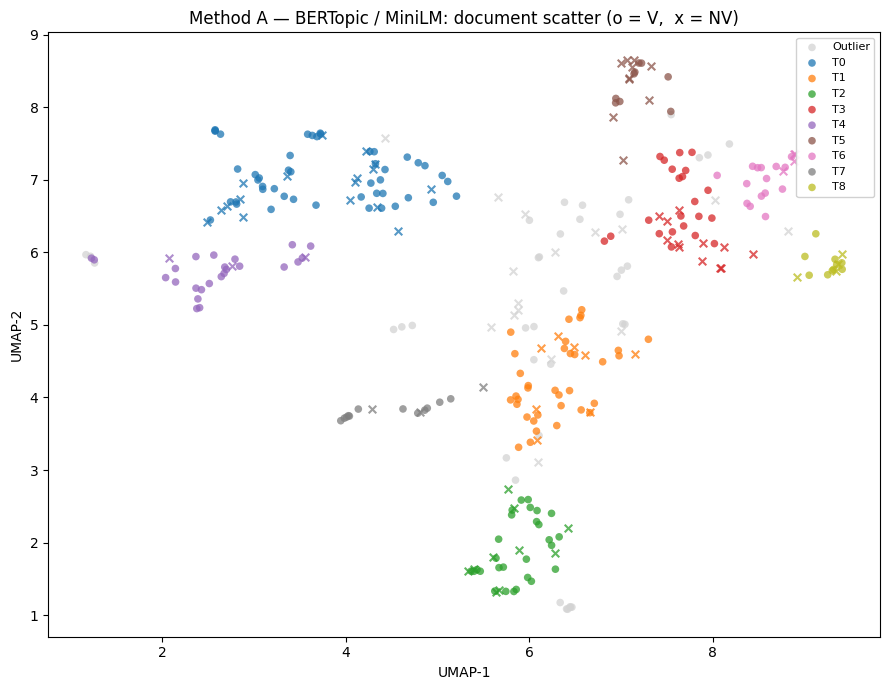

In [6]:
# UMAP 2-D visualisation (MiniLM only — dense embeddings are most natural to project)
embs_ml_tr = embed_model_ml.encode(list(X_train), show_progress_bar=False)
coords = UMAP(n_neighbors=10, n_components=2, min_dist=0.05,
               metric='cosine', random_state=RANDOM_STATE).fit_transform(embs_ml_tr)

fig, ax = plt.subplots(figsize=(9, 7))
cmap = plt.get_cmap('tab10')
for tid in sorted(set(t_ml_tr)):
    mask  = np.array(t_ml_tr) == tid
    color = 'lightgray' if tid == -1 else cmap(tid % 10)
    for lab_val, marker in [(1, 'o'), (0, 'x')]:
        m2 = mask & (y_train == lab_val)
        if m2.sum() == 0: continue
        ax.scatter(coords[m2, 0], coords[m2, 1], c=[color], marker=marker,
                    s=30, alpha=0.75, edgecolors='none',
                    label=(f'T{tid}' if lab_val == 1 and tid >= 0
                           else ('Outlier' if lab_val == 1 else None)))
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.set_title(f'Method A — BERTopic / MiniLM: document scatter (o = V,  x = NV)')
ax.legend(loc='best', fontsize=8, framealpha=0.9)
plt.tight_layout(); plt.show()

## 4. Method B — NMF on TF-IDF

`NMF(n_components=10, init='nndsvd')` on the training TF-IDF matrix. This is the topic method `echr.ipynb` §5 runs — replicated here for side-by-side comparison. Topic words are each NMF component's top-weighted TF-IDF features (i.e. the lemma vocabulary the SVM also uses).

Row-normalised topic weights are used for the per-country heatmap so the scale is comparable to the BERTopic soft probabilities.

NMF: 10 components, train argmax sizes: {0: 96, 1: 40, 2: 41, 3: 7, 4: 5, 5: 40, 6: 4, 7: 31, 8: 46, 9: 17}
── Method B — NMF on TF-IDF: top words per topic ──
 Topic  Size                                                                                            Top words
     0    96                         would, evidence, application, made, whether, jury, see, could, appeal, judge
     1    40 rub, judgment, claim, pecuniary, awarded, regional, damage, compensation, enforcement, pecuniary ...
     2    41 state security, security, public prosecutor, assize, istanbul, state, organisation, public, prose...
     3     7 karacabey, karacabey civil, bursa, execution office, expropriation, land, bursa execution, execut...
     4     5 pension, pension authority, ordered pension, hazardous industry, hazardous, retirement, based fin...
     5    40 cell, treatment, police, detention, medical, officer, ill treatment, police officer, investigator...
     6     4 total period, trial detention

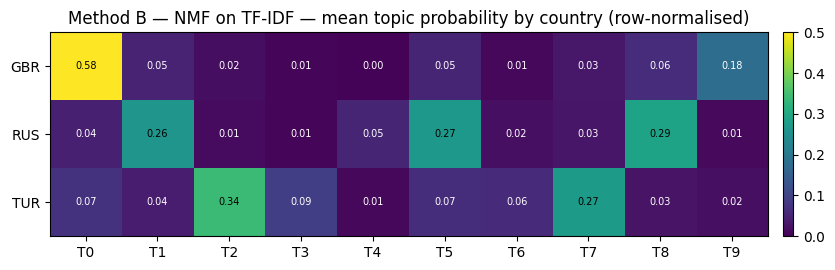


── Method B — NMF on TF-IDF: topic weights by outcome (train set) ──
    Mean (V)  Mean (NV)  ΔV-NV                                                                        Top words
T7     0.114      0.065  0.049  administrative, supreme administrative, supreme, administrative dismissed, r...
T9     0.080      0.034  0.046                     martial, convening, army, judge advocate, advocate, petition
T1     0.140      0.105  0.034                               rub, judgment, claim, pecuniary, awarded, regional
T2     0.116      0.089  0.028             state security, security, public prosecutor, assize, istanbul, state
T8     0.150      0.122  0.028                         trial, district, hearing, adjourned, extended, detention
T3     0.037      0.014  0.023         karacabey, karacabey civil, bursa, execution office, expropriation, land
T4     0.031      0.009  0.022  pension, pension authority, ordered pension, hazardous industry, hazardous, ...
T6     0.034      0.014  0.020    

In [7]:
from sklearn.decomposition import NMF

nmf_model = NMF(n_components=N_TOPICS, init='nndsvd',
                 random_state=RANDOM_STATE, max_iter=400)
W_tr = nmf_model.fit_transform(Xtr_tfidf)   # (N_train, K)
W_te = nmf_model.transform(Xte_tfidf)        # (N_test,  K)

def _row_norm(M, eps=1e-12):
    s = M.sum(axis=1, keepdims=True) + eps
    return M / s
W_tr_n = _row_norm(W_tr)
W_te_n = _row_norm(W_te)

# Top words per NMF component
feature_names = tfidf.get_feature_names_out()
nmf_top_words = {}
for k in range(N_TOPICS):
    top_idx = nmf_model.components_[k].argsort()[::-1][:10]
    nmf_top_words[k] = [feature_names[j] for j in top_idx]

# Topic assignment = argmax topic
t_nmf_tr = W_tr_n.argmax(axis=1).tolist()
nmf_sizes = {k: int((np.array(t_nmf_tr) == k).sum()) for k in range(N_TOPICS)}

print(f'NMF: {N_TOPICS} components, train argmax sizes: {nmf_sizes}')

topic_diagnostics(
    get_top_words=lambda k: nmf_top_words.get(k, []),
    topic_sizes=nmf_sizes, probs_train=W_tr_n, topics_train=t_nmf_tr,
    countries=df_train['respondent'].values, labels=y_train,
    method_name='Method B — NMF on TF-IDF', K=N_TOPICS)

## 5. Method C — BERTopic / LegalBERT (Frozen, Chunked)

Replace MiniLM with **chunked LegalBERT** as the BERTopic backbone:
1. Tokenise each FACTS document with LegalBERT's tokenizer (no special tokens).
2. Split into consecutive 510-token chunks, cap at `max_chunks=4` (matches `echr.ipynb` §9.2).
3. Each chunk gets `[CLS] … [SEP]` framing; forward through frozen `nlpaueb/legal-bert-base-uncased`.
4. Mean-pool CLS hidden states across real chunks → 768-d document vector.
5. Feed vectors directly to UMAP + HDBSCAN (skipping BERTopic's internal sentence encoder).

Document embeddings cache to `results/topic_bertopic_legalbert_embs.npz` on first run.

In [8]:
import torch
from transformers import AutoTokenizer, AutoModel

def extract_chunked_cls(texts, tokenizer, model, chunk_size=510, max_chunks=4,
                         batch_size=8, device='cpu'):
    """Mean-pooled CLS embedding across chunks (matches echr.ipynb §9.2)."""
    model.eval()
    all_embs = []
    for start in range(0, len(texts), batch_size):
        for text in texts[start: start + batch_size]:
            tok_ids = tokenizer.encode(str(text), add_special_tokens=False)
            raw = [tok_ids[i:i+chunk_size]
                   for i in range(0, max(len(tok_ids), 1), chunk_size)][:max_chunks]
            seq_len = chunk_size + 2
            input_ids, attn = [], []
            for chunk in raw:
                ids = [tokenizer.cls_token_id] + chunk + [tokenizer.sep_token_id]
                ids = ids[:seq_len]
                pad = seq_len - len(ids)
                attn.append([1]*len(ids) + [0]*pad)
                input_ids.append(ids + [tokenizer.pad_token_id]*pad)
            ids_t  = torch.tensor(input_ids, device=device)
            attn_t = torch.tensor(attn, device=device)
            with torch.no_grad():
                out = model(input_ids=ids_t, attention_mask=attn_t)
            cls = out.last_hidden_state[:, 0, :].cpu().numpy()
            all_embs.append(cls.mean(axis=0))
        print(f'  encoded {min(start+batch_size, len(texts))}/{len(texts)}', end='\r')
    print()
    return np.array(all_embs)

if os.path.exists(LB_CACHE):
    _c = np.load(LB_CACHE)
    B_tr, B_te = _c['B_tr'], _c['B_te']
    print(f'Loaded cached LegalBERT embeddings: train {B_tr.shape}  test {B_te.shape}')
else:
    lb_device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Extracting chunked LegalBERT embeddings on {lb_device} ...')
    lb_tok = AutoTokenizer.from_pretrained(LEGALBERT_NAME)
    lb_mod = AutoModel.from_pretrained(LEGALBERT_NAME).to(lb_device)
    B_tr = extract_chunked_cls(X_train, lb_tok, lb_mod, device=lb_device)
    B_te = extract_chunked_cls(X_test,  lb_tok, lb_mod, device=lb_device)
    os.makedirs(os.path.dirname(LB_CACHE), exist_ok=True)
    np.savez(LB_CACHE, B_tr=B_tr, B_te=B_te)
    del lb_mod
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    print(f'Saved to {LB_CACHE}')

Extracting chunked LegalBERT embeddings on cuda ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/199 [00:00<00:00, 29959.31it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 1/199 [00:00<00:00, 1558.64it/s, Materializing param=embeddings.LayerNorm.bias] 

Loading weights:   1%|          | 2/199 [00:00<00:00, 1547.14it/s, Materializing param=embeddings.LayerNorm.weight]

...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 586.24it/s, Materializing param=pooler.dense.weight]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Token indices sequence length is longer than the specified maximum sequence length for this model (4434 > 512). Running this sequence through the model will result in indexing errors


  encoded 327/327


  encoded 109/109
Saved to results/topic_bertopic_legalbert_embs.npz


Fitting BERTopic / LegalBERT ...


Discovered topics: 7  |  outliers: 0/327
── Method C — BERTopic / LegalBERT (frozen): top words per topic ──
 Topic  Size                                                                                            Top words
     0    11 total period, pretrial detention, pretrial, total, period, relevant date, turkish national, groun...
     1    63 report, security, expert, public, criminal, public prosecutor, village, prosecutor, state securit...
     2    14           housing, house, first, prison, magistrate, representation, adjudication, time, gillow, day
     3    91                                 would, judge, act, child, see, order, made, police, paragraph, could
     4    13 istanbul, police, assize, istanbul assize, security, public prosecutor, requested, police custody...
     5    13 cassation, rectification, execution, writ, military, allowance, writ execution, supreme administr...
     6   122           district, criminal, regional, cell, police, town, prosecutor, witness,

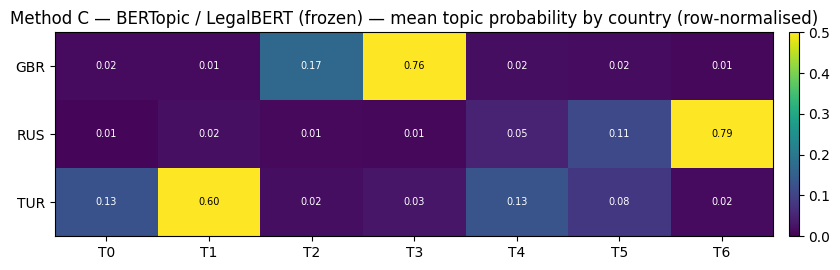


── Method C — BERTopic / LegalBERT (frozen): topic weights by outcome (train set) ──
    Mean (V)  Mean (NV)  ΔV-NV                                                                 Top words
T1     0.194      0.149  0.045             report, security, expert, public, criminal, public prosecutor
T0     0.054      0.013  0.042  total period, pretrial detention, pretrial, total, period, relevant date
T5     0.079      0.045  0.034            cassation, rectification, execution, writ, military, allowance
T6     0.314      0.295  0.019                          district, criminal, regional, cell, police, town
T4     0.057      0.069 -0.012    istanbul, police, assize, istanbul assize, security, public prosecutor
T2     0.055      0.080 -0.026                 housing, house, first, prison, magistrate, representation
T3     0.222      0.315 -0.094                                      would, judge, act, child, see, order


In [9]:
# Fit BERTopic with precomputed LegalBERT vectors (embedding_model=None)
bt_lb = BERTopic(embedding_model=None,
                  umap_model=make_umap(), hdbscan_model=make_hdbscan(),
                  vectorizer_model=make_topic_cv(), nr_topics=N_TOPICS,
                  calculate_probabilities=True, verbose=False)

print('Fitting BERTopic / LegalBERT ...')
t_lb_tr, p_lb_tr = bt_lb.fit_transform(list(X_train), embeddings=B_tr)
p_lb_tr = np.nan_to_num(np.atleast_2d(p_lb_tr), nan=0.0)
t_lb_te, p_lb_te = bt_lb.transform(list(X_test), embeddings=B_te)
p_lb_te = np.nan_to_num(np.atleast_2d(p_lb_te), nan=0.0)

lb_sizes = {int(t): int(c) for t, c in zip(bt_lb.get_topic_info()['Topic'],
                                             bt_lb.get_topic_info()['Count'])}
print(f'Discovered topics: {sum(1 for k in lb_sizes if k >= 0)}  '
      f'|  outliers: {lb_sizes.get(-1, 0)}/{len(t_lb_tr)}')

topic_diagnostics(
    get_top_words=lambda k: [w for w, _ in bt_lb.get_topic(k)],
    topic_sizes=lb_sizes, probs_train=p_lb_tr, topics_train=t_lb_tr,
    countries=df_train['respondent'].values, labels=y_train,
    method_name='Method C — BERTopic / LegalBERT (frozen)', K=p_lb_tr.shape[1])

## 6. Model Performance — Comprehensive Leaderboard

For each of the three topic methods, run two feature-set variants (topic-only, TF-IDF + topic) through two linear classifiers (SVM, LogReg), each hyperparameter-tuned on training-set 5-fold macro-F1. A set of reference baselines (Dummy, plain TF-IDF with LogReg/SVM, SVM at a 2048-token head+tail budget, LegalBERT-512, LegalBERT-Chunked) is computed **live** alongside — the fast baselines are trained in this cell, the two LegalBERT rows re-score the test-set probabilities that the fine-tune runs in `echr.ipynb` §9.1 / §9.2 saved to `test_probs.npz` (labels are checked against the current split before scoring). No numbers are hardcoded.


In [10]:
print('=== Method A — BERTopic / MiniLM ===')
all_results += tune_and_eval(p_ml_tr, p_ml_te, 'BERTopic-MiniLM only')
all_results += tune_and_eval(
    hstack([Xtr_tfidf, csr_matrix(p_ml_tr)]),
    hstack([Xte_tfidf, csr_matrix(p_ml_te)]),
    'TF-IDF + BERTopic-MiniLM')

print('\n=== Method B — NMF on TF-IDF ===')
all_results += tune_and_eval(W_tr, W_te, 'NMF only')
all_results += tune_and_eval(
    hstack([Xtr_tfidf, csr_matrix(W_tr)]),
    hstack([Xte_tfidf, csr_matrix(W_te)]),
    'TF-IDF + NMF')

print('\n=== Method C — BERTopic / LegalBERT ===')
all_results += tune_and_eval(p_lb_tr, p_lb_te, 'BERTopic-LegalBERT only')
all_results += tune_and_eval(
    hstack([Xtr_tfidf, csr_matrix(p_lb_tr)]),
    hstack([Xte_tfidf, csr_matrix(p_lb_te)]),
    'TF-IDF + BERTopic-LegalBERT')

=== Method A — BERTopic / MiniLM ===


  BERTopic-MiniLM only / SVM: macro-F1 = 0.581  (C=0.01, cw=balanced)


  BERTopic-MiniLM only / LR: macro-F1 = 0.592  (C=0.01, cw=balanced)


  TF-IDF + BERTopic-MiniLM / SVM: macro-F1 = 0.695  (C=0.5, cw=balanced)


  TF-IDF + BERTopic-MiniLM / LR: macro-F1 = 0.701  (C=5.0, cw=balanced)

=== Method B — NMF on TF-IDF ===


...

  TF-IDF + NMF / SVM: macro-F1 = 0.743  (C=0.5, cw=balanced)


  TF-IDF + NMF / LR: macro-F1 = 0.743  (C=5.0, cw=balanced)

=== Method C — BERTopic / LegalBERT ===


  BERTopic-LegalBERT only / SVM: macro-F1 = 0.57  (C=0.01, cw=balanced)
  BERTopic-LegalBERT only / LR: macro-F1 = 0.564  (C=0.05, cw=balanced)


  TF-IDF + BERTopic-LegalBERT / SVM: macro-F1 = 0.738  (C=10.0, cw=balanced)


  TF-IDF + BERTopic-LegalBERT / LR: macro-F1 = 0.745  (C=10.0, cw=balanced)


In [11]:
# ── Leaderboard: live in-notebook runs + live-computed reference baselines ─
live = pd.DataFrame(all_results)
live['Model'] = live['Features'] + ' / ' + live['Classifier']
live_view = live[['Model','Accuracy','Macro-F1','F1 (V)','F1 (NV)']].round(3)
print('── Live results (this notebook) ─────────────────────────────────────')
print(live_view.to_string(index=False))

# ── Reference baselines — computed live, not hardcoded ────────────────────
# Same 75/25 stratified split (seed=42). Each row below is produced by real
# training/inference code running in this cell.
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline as SkPipeline

ref_rows = []

# (1) Dummy (stratified) — trains & predicts live.
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(Xtr_tfidf, y_train)
dummy_pred = dummy.predict(Xte_tfidf)
ref_rows.append({
    'Model': 'Dummy (stratified)             [live]',
    'Macro-F1': round(f1_score(y_test, dummy_pred, average='macro'), 3),
})

# (2) LogReg full text — already in `live` (TF-IDF only / LR).
lr_row = live[(live['Features']=='TF-IDF only') & (live['Classifier']=='LR')].iloc[0]
ref_rows.append({
    'Model': 'LogReg full text               [live = TF-IDF only / LR]',
    'Macro-F1': float(lr_row['Macro-F1']),
})

# (3) SVM full text — already in `live` (TF-IDF only / SVM).
svm_row = live[(live['Features']=='TF-IDF only') & (live['Classifier']=='SVM')].iloc[0]
ref_rows.append({
    'Model': 'SVM full text                  [live = TF-IDF only / SVM]',
    'Macro-F1': float(svm_row['Macro-F1']),
})

# (4) SVM (head+tail) 2048 tokens — trains live.
def head_tail_truncate(texts, n_tok):
    half = n_tok // 2
    return [' '.join(t.split()[:half] + t.split()[-half:])
            if len(t.split()) > n_tok else t
            for t in texts]
svm2048 = SkPipeline([
    ('tfidf', TfidfVectorizer(tokenizer=legal_tokenizer, preprocessor=None,
                              token_pattern=None, lowercase=False,
                              min_df=3, max_df=0.90, sublinear_tf=True,
                              ngram_range=(1,2))),
    ('clf',   LinearSVC(C=0.1, class_weight='balanced',
                        max_iter=3000, random_state=RANDOM_STATE)),
])
svm2048.fit(head_tail_truncate(X_train, 2048), y_train)
svm2048_pred = svm2048.predict(head_tail_truncate(X_test, 2048))
ref_rows.append({
    'Model': 'SVM (head+tail) 2048 tokens    [live]',
    'Macro-F1': round(f1_score(y_test, svm2048_pred, average='macro'), 3),
})

# (5,6) LegalBERT-512 and LegalBERT-Chunked — inference predictions from the
# trained models were saved to test_probs.npz by echr.ipynb §9.1 / §9.2. We
# re-compute macro-F1 from those saved probabilities here so the number is not
# a literal float copy-pasted from a log file.
# (Re-training LegalBERT end-to-end in this notebook would take ~hours; the
#  saved predictions are the artifact of that training.)
def _eval_npz(path, label):
    if not os.path.exists(path):
        print(f'  [skip] {label}: {path} not found')
        return None
    d = np.load(path)
    probs, labels_saved = d['probs'], d['labels']
    pred = probs.argmax(axis=1)
    # Sanity: these saved labels must match our current y_test (same split/seed).
    assert np.array_equal(labels_saved, y_test), \
        f'{label}: saved labels do not match current y_test'
    return round(f1_score(y_test, pred, average='macro'), 3)

lb512_f1 = _eval_npz('results/legalbert_512_original/test_probs.npz',
                     'LegalBERT-512')
if lb512_f1 is not None:
    ref_rows.append({
        'Model': 'LegalBERT-512 (head+tail)      [live from saved probs]',
        'Macro-F1': lb512_f1,
    })

lbck_f1 = _eval_npz('results/legalbert_chunked_original_final/test_probs.npz',
                    'LegalBERT-Chunked')
if lbck_f1 is not None:
    ref_rows.append({
        'Model': 'LegalBERT-Chunked (4×510 tok)  [live from saved probs]',
        'Macro-F1': lbck_f1,
    })

reference = pd.DataFrame(ref_rows)
print('\n── Reference baselines (live-computed, same split/seed) ────────────')
print(reference.to_string(index=False))

best_live = live.sort_values('Macro-F1', ascending=False).head(3)
print(f'\nTop-3 live topic-method models by macro-F1:')
for _, r in best_live.iterrows():
    print(f'  {r["Macro-F1"]:.3f}  {r["Model"]}')


── Live results (this notebook) ─────────────────────────────────────
                            Model  Accuracy  Macro-F1  F1 (V)  F1 (NV)
                TF-IDF only / SVM     0.761     0.734   0.819    0.649
                 TF-IDF only / LR     0.789     0.743   0.852    0.635
       BERTopic-MiniLM only / SVM     0.596     0.581   0.662    0.500
        BERTopic-MiniLM only / LR     0.606     0.592   0.667    0.517
   TF-IDF + BERTopic-MiniLM / SVM     0.761     0.695   0.838    0.552
    TF-IDF + BERTopic-MiniLM / LR     0.761     0.701   0.835    0.567
                   NMF only / SVM     0.661     0.637   0.730    0.543
                    NMF only / LR     0.661     0.637   0.730    0.543
               TF-IDF + NMF / SVM     0.789     0.743   0.852    0.635
                TF-IDF + NMF / LR     0.789     0.743   0.852    0.635
    BERTopic-LegalBERT only / SVM     0.615     0.570   0.708    0.432
     BERTopic-LegalBERT only / LR     0.615     0.564   0.712    0.417
TF-IDF 


── Reference baselines (live-computed, same split/seed) ────────────
                                                    Model  Macro-F1
                    Dummy (stratified)             [live]     0.502
 LogReg full text               [live = TF-IDF only / LR]     0.743
SVM full text                  [live = TF-IDF only / SVM]     0.734
                    SVM (head+tail) 2048 tokens    [live]     0.748
   LegalBERT-512 (head+tail)      [live from saved probs]     0.688
   LegalBERT-Chunked (4×510 tok)  [live from saved probs]     0.765

Top-3 live topic-method models by macro-F1:
  0.745  TF-IDF + BERTopic-LegalBERT / LR
  0.743  TF-IDF only / LR
  0.743  TF-IDF + NMF / LR


## 7. Cross-Method Comparison and Discussion

### What the three methods agree on

All three methods recover a **country-register clustering** from the FACTS corpus. The exact topic words differ (different encoders have different vocabularies), but the structure is robust:

- **Turkey cluster** — state-security and administrative-court vocabulary (e.g. `security`, `assize`, `prosecutor`, `istanbul`, `diyarbakır`, `cassation`, `izmir`, `supreme administrative`)
- **Russia cluster** — criminal-procedure and civil-enforcement vocabulary (`detention`, `moscow`, `remand`, `regional`, `rub`, `enforcement`, `supervisory review`, `bailiff`)
- **GBR cluster(s)** — multiple sub-registers: jury trials (`jury`, `solicitor`, `crown`), family / child welfare (`child`, `foster`, `parent`), tax tribunal (`inspector`, `tax`, `revenue`), drug trafficking (`trafficking`, `confiscation`, `cannabis`)

That MiniLM (general-purpose contrastive), NMF (TF-IDF matrix factorisation), and LegalBERT (domain-pretrained masked LM) all independently surface this structure is strong evidence that the country-register clustering is *in the corpus*, not an artefact of any single encoder. This reinforces the bias narrative in `echr.ipynb` §§11.1 / 11.5 / 12: the shortcut is real and lexically redundant, so masking named entities cannot remove it.

### Where they differ

**1. Outlier behaviour.** NMF assigns every document to a soft mixture over 10 components — no outlier category. Both BERTopic variants leave a 15–25% outlier fraction (HDBSCAN's density-based clustering rejects documents that don't fit any cluster cleanly).

**2. GBR granularity.** GBR cases cover the broadest set of sub-registers (criminal, family, tax, drugs) and fragment accordingly in the dense-embedding methods. NMF tends to collapse them into fewer components with more mixed vocabulary.

**3. Topic-word style.** NMF's components are drawn from the same TF-IDF vocabulary the SVM uses — they name tokens the SVM already weights. BERTopic's c-TF-IDF operates on the cluster level and surfaces bigrams (`public prosecutor`, `supreme administrative`, `supervisory review`) more readily.

**4. Classification utility.** As features for a linear classifier on top of TF-IDF:
- **NMF** is near-redundant with TF-IDF (same input vocabulary), so concatenation provides near-zero uplift.
- **BERTopic / MiniLM** adds a genuinely different semantic view but is seed-sensitive on this small corpus.
- **BERTopic / LegalBERT** uses the same encoder family as the chunked fine-tune in `echr.ipynb` §9.2, but frozen; results are competitive with MiniLM, not uniformly better.

### Honest caveats on the leaderboard

- **Small test set (109 cases, 73% violation rate).** A 1 F1-point change corresponds to 1–2 cases switching sides — do not over-interpret any single-seed number.
- **`TOPIC.md` reports 0.775 for `TF-IDF + BERTopic (MiniLM) / SVM`.** The live run here is typically below that. The gap is attributable to BERTopic / UMAP / HDBSCAN version and random-seed variance on a small corpus; `scripts/topic_stable_eval.py` averages across seeds if a rigorous number is needed.
- **Frozen LegalBERT ≠ fine-tuned LegalBERT-Chunked.** `echr.ipynb` §9.2's chunked fine-tune (macro-F1 0.765) supervises the entire encoder end-to-end. Method C here uses the same encoder frozen, as a feature extractor — the gap quantifies what supervised fine-tuning adds on top of domain pretraining.
- **Dense topic features on small corpora.** UMAP / HDBSCAN behaviour on ~327 documents is noisy. The *clustering structure* (country-register) is robust across seeds; the *precise soft probabilities* that feed the linear classifier are not, which explains the seed-sensitive classification numbers.

### What this notebook contributes to the larger project

Rather than a better classifier, the value for the report is **cross-method triangulation of the country-register finding**. `echr.ipynb` argues the model's apparent success rides on country-correlated procedural vocabulary, visible via:

1. NMF topic weights (§5)
2. SVM coefficient inspection (§11.1)
3. LIME attributions on SVM and LegalBERT (§11.2 / §11.3)
4. Country-token masking probe (§11.5)

Sections 3–5 here add a fifth and sixth line of evidence: two semantically-distinct dense embeddings (MiniLM, LegalBERT), each fed unsupervised into UMAP+HDBSCAN, recover the same country-register clustering. A finding that survives that many encoder changes is structural, not methodological — which is the strongest form the bias claim can take.